In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv("P1_Churn_Modelling.csv")

In [5]:
df.shape

(10000, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
col_names = df.columns

col_names

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [10]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


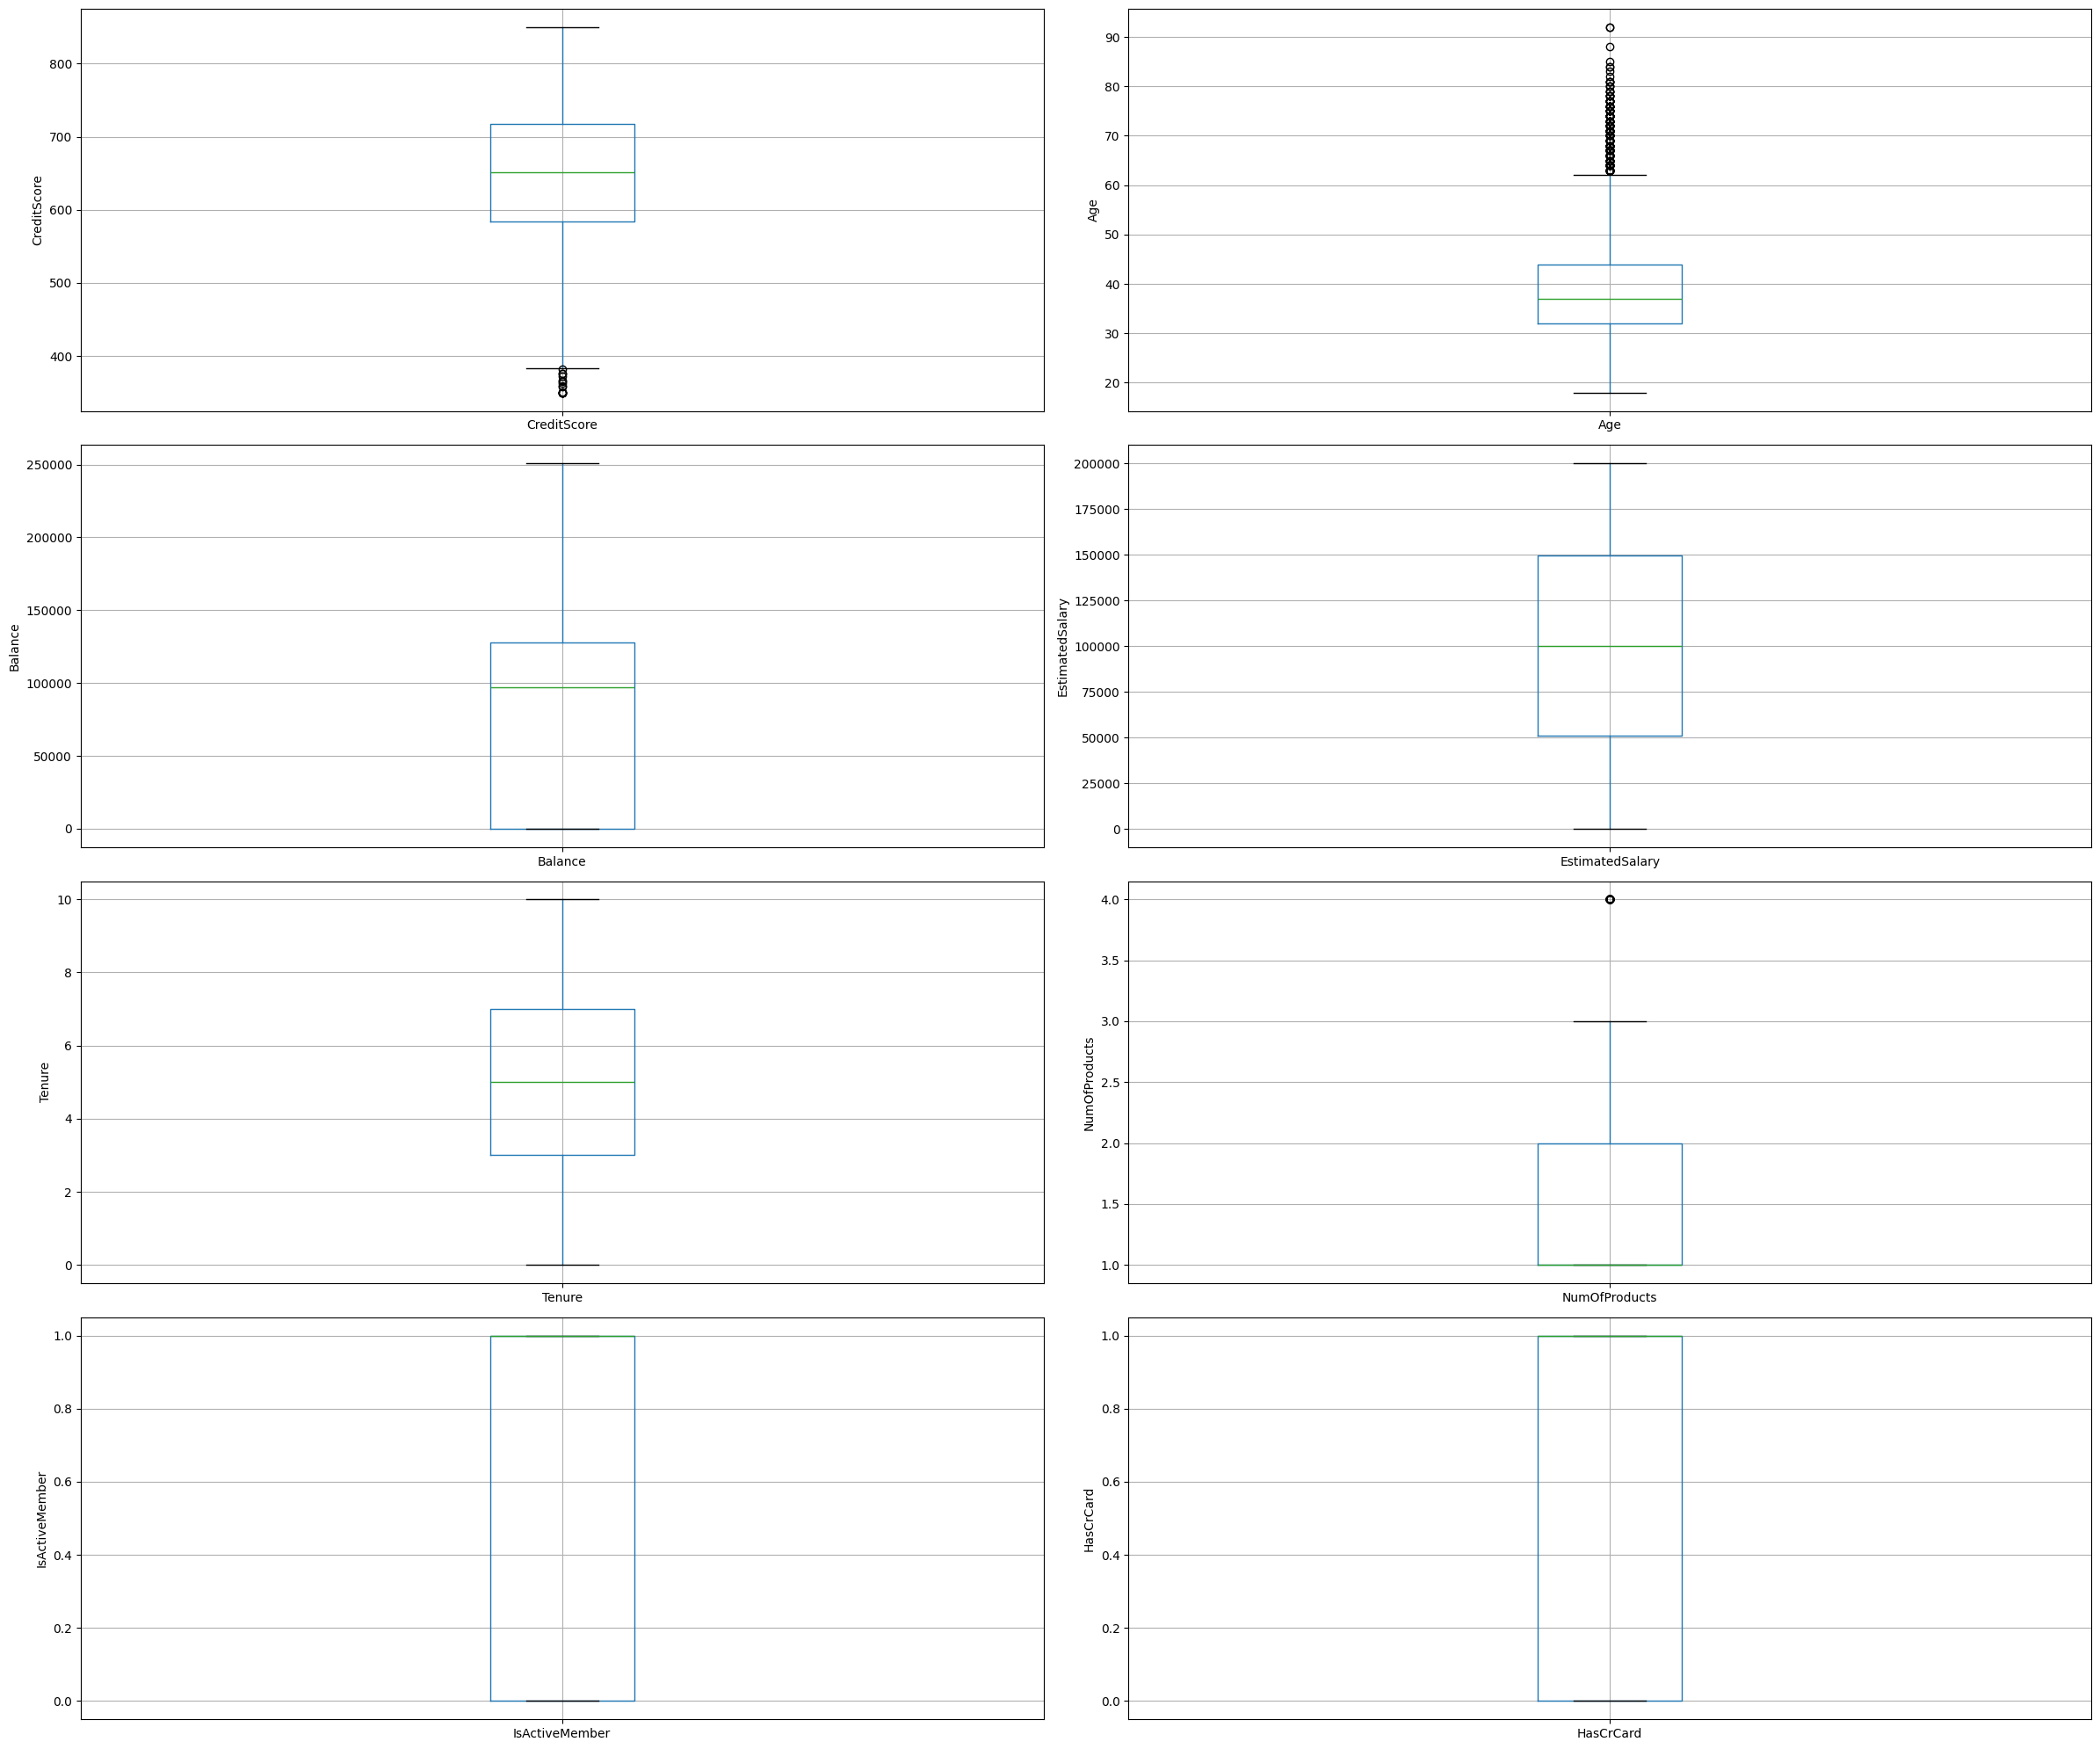

In [11]:
plt.figure(figsize=(24, 20))

# Define features for visualization
features = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary',
            'Tenure', 'NumOfProducts', 'IsActiveMember', 'HasCrCard']

# Plot boxplots for each feature
for i, feature in enumerate(features):
    plt.subplot(4, 2, i + 1)
    fig = df.boxplot(column=feature)
    fig.set_title('')
    fig.set_ylabel(feature)

# Show plots
plt.tight_layout()
plt.show()

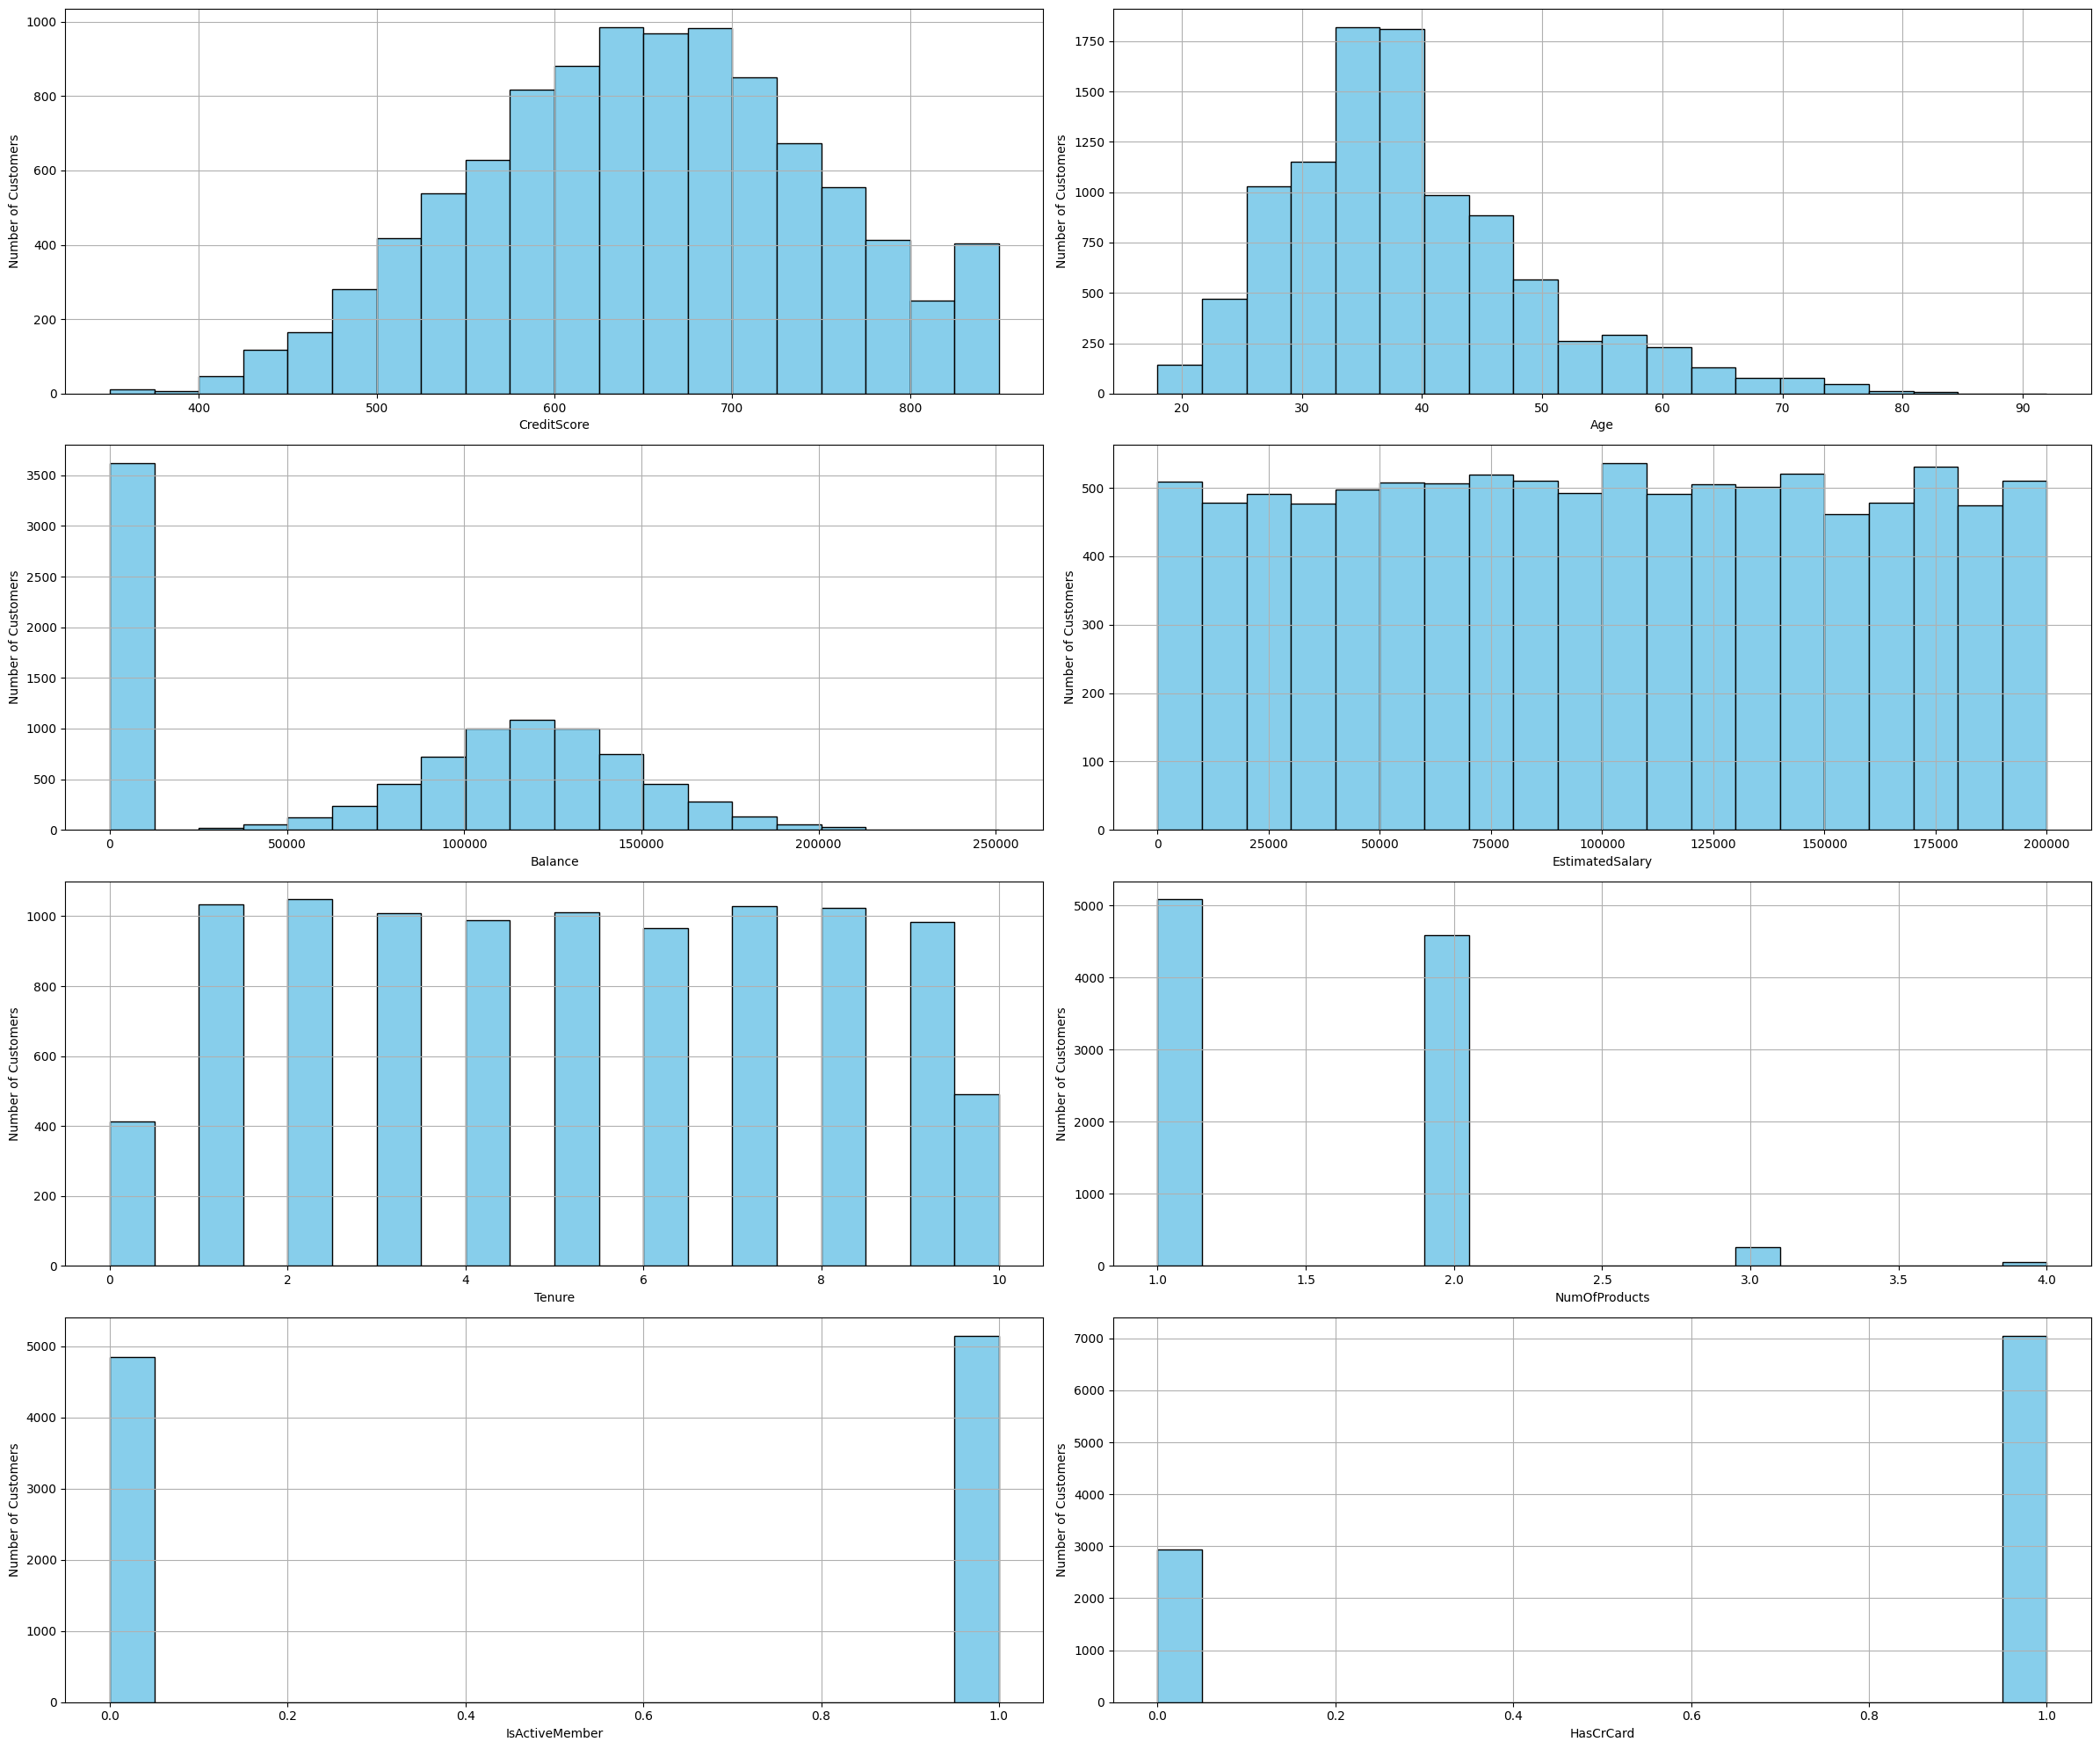

In [12]:
plt.figure(figsize=(24, 20))

# Define numerical features for visualization
features = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary',
            'Tenure', 'NumOfProducts', 'IsActiveMember', 'HasCrCard']

# Plot histograms for each feature
for i, feature in enumerate(features):
    plt.subplot(4, 2, i + 1)
    fig = df[feature].hist(bins=20, color='skyblue', edgecolor='black')
    fig.set_xlabel(feature)
    fig.set_ylabel('Number of Customers')

# Show plots
plt.tight_layout()
plt.show()

In [13]:
# Drop unnecessary columns
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [14]:
# Encode categorical variables
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [15]:
# Define features and target variable
X = df.drop(columns=['Exited'])
y = df['Exited']

In [16]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [18]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
# Train models
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(probability=True, kernel='linear'),
    'Decision Tree': DecisionTreeClassifier()
}

In [20]:
# Evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    report = classification_report(y_test, y_pred)

    results[name] = {
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'Classification Report': report
    }

    print(f"{name} Results:\n")
    print(f"Accuracy: {accuracy:.4f}")
    if roc_auc is not None:
        print(f"ROC-AUC Score: {roc_auc:.4f}")
    print(report)
    print("-" * 50)


KNN Results:

Accuracy: 0.7785
ROC-AUC Score: 0.7754
              precision    recall  f1-score   support

           0       0.89      0.82      0.86      1593
           1       0.47      0.61      0.53       407

    accuracy                           0.78      2000
   macro avg       0.68      0.71      0.69      2000
weighted avg       0.80      0.78      0.79      2000

--------------------------------------------------
Naive Bayes Results:

Accuracy: 0.7540
ROC-AUC Score: 0.7642
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1593
           1       0.42      0.57      0.48       407

    accuracy                           0.75      2000
   macro avg       0.65      0.68      0.66      2000
weighted avg       0.79      0.75      0.77      2000

--------------------------------------------------
SVM Results:

Accuracy: 0.7480
ROC-AUC Score: 0.7425
              precision    recall  f1-score   support

           0       0.8

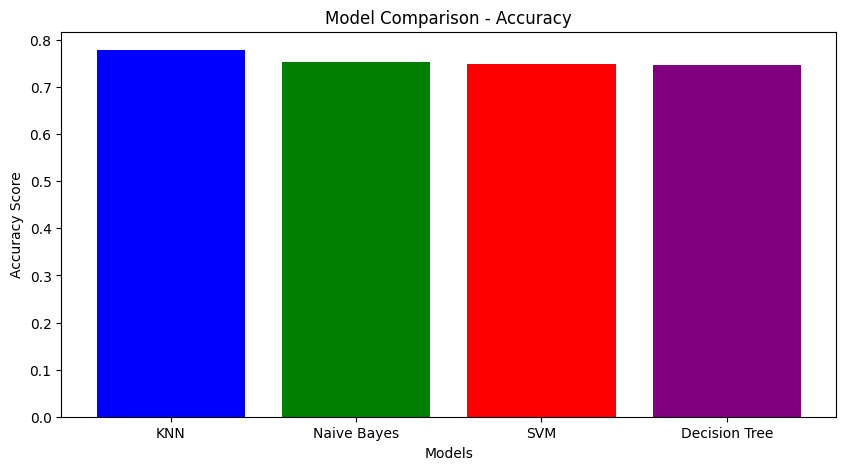

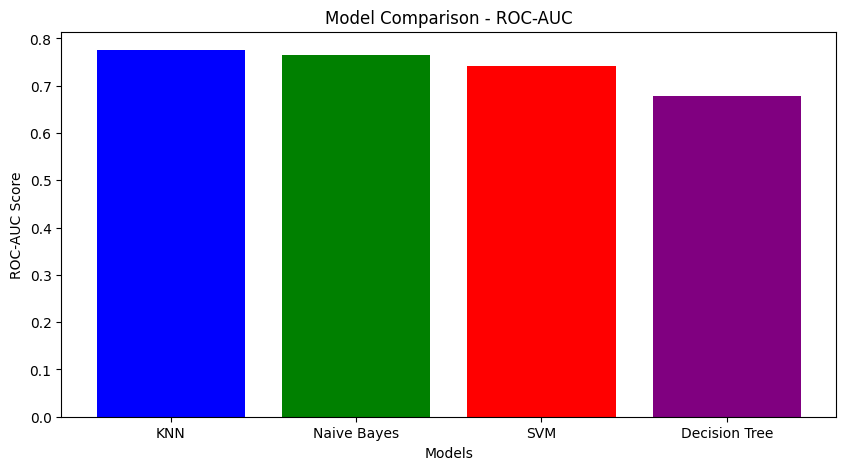

In [21]:
# Compare model performances
accuracy_scores = [results[name]['Accuracy'] for name in models.keys()]
roc_auc_scores = [results[name]['ROC-AUC'] for name in models.keys()]

plt.figure(figsize=(10, 5))
plt.bar(models.keys(), accuracy_scores, color=['blue', 'green', 'red', 'purple'])
plt.xlabel("Models")
plt.ylabel("Accuracy Score")
plt.title("Model Comparison - Accuracy")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(models.keys(), roc_auc_scores, color=['blue', 'green', 'red', 'purple'])
plt.xlabel("Models")
plt.ylabel("ROC-AUC Score")
plt.title("Model Comparison - ROC-AUC")
plt.show()